In [1]:
%matplotlib widget
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
import pickle
from scipy.interpolate import RegularGridInterpolator
import shutil
from p1 import read_IJK_from_tecplot_dat
import re
from p1 import XYZTransform

In [2]:
def transform_piv_data(piv, step, I, J, K, pts__, interp_fill_value=None):
    X = piv[:, 0].reshape((K, J, I))
    Y = piv[:, 1].reshape((K, J, I))
    Z = piv[:, 2].reshape((K, J, I))
    U = piv[:, 3].reshape((K, J, I))
    V = piv[:, 4].reshape((K, J, I))
    W = piv[:, 5].reshape((K, J, I))
    xs = X[0, 0, :]
    ys = Y[0, :, 0]
    zs = Z[:, 0, 0]
    uvw = np.stack([U.transpose(2,1,0), V.transpose(2,1,0), W.transpose(2,1,0)], axis=-1) * step # shape: (I, J, K, 3)
    interp = RegularGridInterpolator((xs, ys, zs), uvw, bounds_error=False, fill_value=interp_fill_value) # fill_value=None, allow extrapolation

    uvw__ = interp(pts__) # interpolation
    u_pts = uvw__[:, 0].reshape(gx__.shape)
    v_pts = uvw__[:, 1].reshape(gx__.shape)
    w_pts = uvw__[:, 2].reshape(gx__.shape)
    uvw_pts = np.stack([u_pts, v_pts, w_pts])

    return uvw_pts


def match_piv_files(data_dict, head_tail):
    f0 = data_dict['f0'] 
    f1 = data_dict['f1']
    step = data_dict['step']

    piv_folder = data_dict['piv_folder']
    piv_files = sorted(os.listdir(piv_folder))[f0:f1][::step]
    
    im_folder = data_dict['im_folder']
    piv_frame0_idx = data_dict['piv_frame0_idx']
    im_files = sorted(os.listdir(im_folder))[piv_frame0_idx+f0-head_tail*step: piv_frame0_idx+f1+head_tail*step][::step]
    
    # get full path
    piv_files = [os.path.join(piv_folder, item) for item in piv_files]
    im_files = [os.path.join(im_folder, item) for item in im_files]

    return piv_files, im_files
    


def divergence_func(uvw, dx=1.0, dy=1.0, dz=1.0):
    U, V, W = uvw[:, 0], uvw[:, 1], uvw[:, 2]
    
    du_dx = (U[:, :, :, 2:] - U[:, :, :, :-2]) / (2.0 * dx)   # (N,Z,Y,X-2)
    dv_dy = (V[:, :, 2:, :] - V[:, :, :-2, :]) / (2.0 * dy)   # (N,Z,Y-2,X)
    dw_dz = (W[:, 2:, :, :] - W[:, :-2, :, :]) / (2.0 * dz)   # (N,Z-2,Y,X)
    
    div = du_dx[:, 1:-1, 1:-1, :] + dv_dy[:, 1:-1, :, 1:-1] + dw_dz[:, :, 1:-1, 1:-1]  # (N,Z-2,Y-2,X-2)
    
    return np.abs(div).mean(axis=(1,2,3))



In [3]:
# PSFE space 
center_x = 1061 
center_y = 1092
pixel_size = 0.0392
alignment_file = 'alignment16_0127_1000.npy'  # tp16, new net, FOV 1000
alignment_dict = np.load(alignment_file, allow_pickle=True).item()
A = np.concatenate((alignment_dict['affine3x4'], np.array([[0, 0, 0, 1]])), axis=0)
xyzfunc = XYZTransform(alignment_dict)   # more elaborated transform

im_relative_ids = [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]  # temporal sequence
head_tail = 5 # there should be more images than velocity frames, so a head and a tail should be defined


In [4]:
crop_shift = 80
# crop_shift = 160
# jet datasets
dd_d1200jet1step1 = dict(
    data_title = 'd1200jet1step1',
    piv_folder = '/zjbd/zd1/dafei/PIV_data/TOMO/exp20251216/D1200_TP_Jet_R1/TomographicPIV_48x48x48_75%ov_1000_1600/SlidAvg L=5',
    piv_frame0_idx = 999, # the index of the first tomo piv file in the whole video. davis starts with 1 in indexing while in python it's 0 
    im_folder = '/zjbd/zd1/dafei/PIV_data/PSFE/exp20251216/D2000_TP_Jet_R1',
    f0 = 10,  # f0 and f1 define the time range that will be used
    f1 = 560,
    step = 1,  # used for data augmentation, 1 means no skipping frames and 2 means skipping 1 frames, etc.
    roi_cropping_shift = crop_shift, 
)

dd_d1200jet2step1 = dict(
    data_title = 'd1200jet2step1',
    piv_folder = '/zjbd/zd1/dafei/PIV_data/TOMO/exp20251216/D1200_TP_Jet_R2/TomographicPIV_48x48x48_75%ov_600_1200/SlidAvg L=5',
    piv_frame0_idx = 599, 
    im_folder = '/zjbd/zd1/dafei/PIV_data/PSFE/exp20251216/D1200_TP_Jet_R2',
    f0 = 10,
    f1 = 560,
    step = 1,
    roi_cropping_shift = crop_shift, 
)


dd_d1600jet1step1 = dict(
    data_title = 'd1600jet1step1',
    piv_folder = '/zjbd/zd1/dafei/PIV_data/TOMO/exp20251216/D1600_TP_Jet_R1/TomographicPIV_48x48x48_75%ov_100_800/TomoPostProcessing/SlidAvg L=5',
    piv_frame0_idx = 99, 
    im_folder = '/zjbd/zd1/dafei/PIV_data/PSFE/exp20251216/D1600_TP_Jet_R1',
    f0 = 10,
    f1 = 660,
    step = 1,
    roi_cropping_shift = crop_shift,
)


dd_d2000jet1step1 = dict(
    data_title = 'd2000jet1step1',
    piv_folder = '/zjbd/zd1/dafei/PIV_data/TOMO/exp20251216/D2000_TP_Jet_R1/TomographicPIV_48x48x48_75%ov_100_500/SlidAvg L=5',
    piv_frame0_idx = 99, 
    im_folder = '/zjbd/zd1/dafei/PIV_data/PSFE/exp20251216/D2000_TP_Jet_R1',
    f0 = 10,
    f1 = 360,
    step = 1,
    roi_cropping_shift = crop_shift,  # 96
)


dd_d2000jet2step1 = dict(
    data_title = 'd2000jet2step1',
    piv_folder = '/zjbd/zd1/dafei/PIV_data/TOMO/exp20251216/D2000_TP_Jet_R2/TomographicPIV_48x48x48_75%ov_400_1400/SlidAvg L=5',
    piv_frame0_idx = 399, 
    im_folder = '/zjbd/zd1/dafei/PIV_data/PSFE/exp20251216/D2000_TP_Jet_R2',
    f0 = 10,
    f1 = 960,
    step = 1,
    roi_cropping_shift = crop_shift,  # 48

)

# dd_d2000jet2step2 = dict(
#     data_title = 'd2000jet2step2',
#     # piv_folder = '/zjbd/zd1/dafei/PIV_data/TOMO/exp20251216/D2000_TP_Jet_R2/2_TomographicPIV_48x48x48_75%ov_400_2_1400/SlidAvg L=5',
#     piv_folder = '/zjbd/zd1/dafei/PIV_data/TOMO/exp20251216/D2000_TP_Jet_R2/TomographicPIV_48x48x48_75%ov_400_1400/SlidAvg L=5',
#     piv_frame0_idx = 399, 
#     im_folder = '/zjbd/zd1/dafei/PIV_data/PSFE/exp20251216/D2000_TP_Jet_R2',
#     f0 = 100,
#     f1 = 800,
#     step = 2,
#     roi_cropping_shift = 128,  # 32
    
# )

# swirl datasets

# d1200
dd_d1200swirl1step1 = dict(
    data_title = 'd1200swirl1step1',
    piv_folder = '/zjbd/zd1/dafei/PIV_data/TOMO/exp20251216/D1200_TP_Swirl_R1/TomographicPIV_48x48x48_75%ov_100_500/SlidAvg L=5',
    piv_frame0_idx = 99, 
    im_folder = '/zjbd/zd1/dafei/PIV_data/PSFE/exp20251216/D1200_TP_Swirl_R1',
    f0 = 10,
    f1 = 210,
    step = 1,
    roi_cropping_shift = crop_shift,
)

dd_d1200swirl2step1 = dict(
    data_title = 'd1200swirl2step1',
    piv_folder = '/zjbd/zd1/dafei/PIV_data/TOMO/exp20251216/D1200_TP_Swirl_R2/TomographicPIV_48x48x48_75%ov_100_500/SlidAvg L=5',
    piv_frame0_idx = 99, 
    im_folder = '/zjbd/zd1/dafei/PIV_data/PSFE/exp20251216/D1200_TP_Swirl_R2',
    f0 = 10,
    f1 = 210,
    step = 1,
    roi_cropping_shift = crop_shift,
)


dd_d1600swirl1step1 = dict(
    data_title = 'd1600swirl1step1',
    piv_folder = '/zjbd/zd1/dafei/PIV_data/TOMO/exp20251216/D1600_TP_Swirl_R1/TomographicPIV_48x48x48_75%ov_100_500/TomoPostProcessing/SlidAvg L=5',
    piv_frame0_idx = 99, 
    im_folder = '/zjbd/zd1/dafei/PIV_data/PSFE/exp20251216/D1600_TP_Swirl_R1',
    f0 = 10,
    f1 = 210,
    step = 1,
    roi_cropping_shift = crop_shift,
)

dd_d2000swirl1step1 = dict(
    data_title = 'd2000swirl1step1',
    piv_folder = '/zjbd/zd1/dafei/PIV_data/TOMO/exp20251216/D2000_TP_Swirl_R1/TomographicPIV_48x48x48_75%ov_100_400/SlidAvg L=5',
    piv_frame0_idx = 99, 
    im_folder = '/zjbd/zd1/dafei/PIV_data/PSFE/exp20251216/D2000_TP_Swirl_R1',
    f0 = 10,
    f1 = 210,
    step = 1,
    roi_cropping_shift = crop_shift,
)


dd_d2000swirl2step1 = dict(
    data_title = 'd2000swirl2step1',
    piv_folder = '/zjbd/zd1/dafei/PIV_data/TOMO/exp20251216/D2000_TP_Swirl_R2/TomographicPIV_48x48x48_75%ov_100_400/SlidAvg L=5',
    piv_frame0_idx = 99, 
    im_folder = '/zjbd/zd1/dafei/PIV_data/PSFE/exp20251216/D2000_TP_Swirl_R2',
    f0 = 10,
    f1 = 210,
    step = 1,
    roi_cropping_shift = crop_shift,
)



In [5]:
# dd_jets = [dd_d1200jet1step1, dd_d1200jet2step1, dd_d1600jet1step1, dd_d2000jet1step1, dd_d2000jet2step1]
dd_jets = [dd_d1200jet1step1, dd_d1200jet2step1, dd_d1600jet1step1, dd_d2000jet1step1]
dd_swirls = [dd_d1200swirl1step1, dd_d1200swirl2step1, dd_d1600swirl1step1, dd_d2000swirl1step1, dd_d2000swirl2step1]

dd_list = dd_jets
# dd_list = dd_swirls

In [6]:
# prepare 3D grid in PSFE space and map to tomo space
# xy
# ww, hh = 512, 768  # devisible by de_m
ww, hh = 640, 800
# ww, hh = 512, 512  # devisible by de_m
# ww, hh = 256, 256  # devisible by de_m

# set z range in psfe space such that the corresponding tomo space has a proper z range
z0 = 0.4
z1 = 20.0-1.8

de_m = 16  # demagnification in x and y
I_, J_, K_ = int(ww/de_m), int(hh/de_m), 25  # 3D voxelization of the volume
print(f'voxels of the PSFE volume: I_-{I_}, J_-{J_}, K_-{K_}')

# 3D grid in PSFE space
xy05 = pixel_size*ww/2
w05, h05 = ww//2, hh//2
r0, r1 = center_y-h05, center_y+h05   # cropping ends
c0, c1 = center_x-w05, center_x+w05  # cropping ends
x0 = (c0-center_x)*pixel_size  # left, negative x
x1 = (c1-center_x)*pixel_size  # right, positive x
y0 = (center_y-r0)*pixel_size  # up, positive y
y1 = (center_y-r1)*pixel_size  # down, negative y
print(f'PSFE roi: x range ({x0}, {x1}), y range ({y0}, {y1}), zrange ({z0}, {z1})')

# coordinate transform
xx = np.linspace(x0, x1, I_) 
yy = np.linspace(y0, y1, J_)
zz = np.linspace(z0, z1, K_)
gx, gy, gz = np.meshgrid(xx, yy, zz, indexing='xy')   # indexing should be xy 
pts = np.c_[gx.flatten(), gy.flatten(), gz.flatten()]
# pts_ = (A @ np.c_[(pts, np.ones((pts.shape[0], 1)))].T)[:3, :].T  # affine transform
pts_ = xyzfunc.direct_transform(pts)  # transform to tomo space
gx_ = pts_[:, 0].reshape(gx.shape).transpose(2, 0, 1)  # reshape to K_, J_, I_
gy_ = pts_[:, 1].reshape(gx.shape).transpose(2, 0, 1)
gz_ = pts_[:, 2].reshape(gx.shape).transpose(2, 0, 1)
gx__ = gx_  # z filtering can be done here
gy__ = gy_
gz__ = gz_
pts__ = np.c_[gx__.flatten(), gy__.flatten(), gz__.flatten()]  # important

voxels of the PSFE volume: I_-40, J_-50, K_-25
PSFE roi: x range (-12.544, 12.544), y range (15.68, -15.68), zrange (0.4, 18.2)


d1600jet1step1
the first


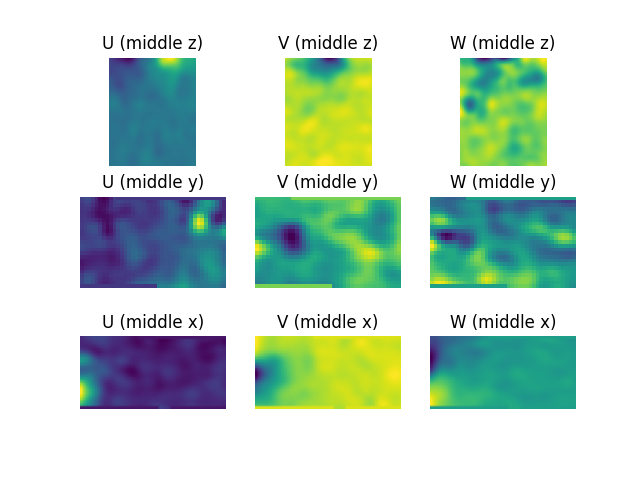

the last


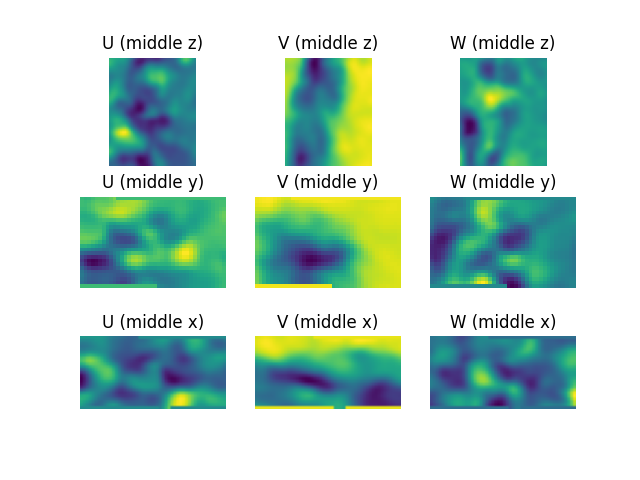

In [7]:
# demonstrate one dataset

dd = dd_list[2]

data_title = dd['data_title']
step = dd['step']

print(data_title)

piv_files, im_files = match_piv_files(dd, head_tail)
assert (len(piv_files)+head_tail*2) == len(im_files), "piv-im mismatch"

I, J, K = read_IJK_from_tecplot_dat(piv_files[0])

# f0
piv = np.loadtxt(piv_files[0], skiprows=4)
uvw_pts_f0 = transform_piv_data(piv, step, I, J, K, pts__, interp_fill_value=0.0)
# f1 
piv = np.loadtxt(piv_files[-1], skiprows=4)
uvw_pts_f1 = transform_piv_data(piv, step, I, J, K, pts__, interp_fill_value=0.0)


# show interpolation results
u_pts, v_pts, w_pts = uvw_pts_f0[0], uvw_pts_f0[1], uvw_pts_f0[2]
print('the first')
# print(f'U range:({u_pts.min()}, {u_pts.max()})')
# print(f'V range:({v_pts.min()}, {v_pts.max()})')
# print(f'W range:({w_pts.min()}, {w_pts.max()})')
z_middle_idx = u_pts.shape[0]//2
y_middle_idx = u_pts.shape[1]//2
x_middle_idx = u_pts.shape[2]//2

plt.figure()
plt.subplot(331); plt.imshow(u_pts[z_middle_idx, :, :]); plt.title('U (middle z)'); plt.axis('off')
plt.subplot(332); plt.imshow(v_pts[z_middle_idx, :, :]); plt.title('V (middle z)'); plt.axis('off')
plt.subplot(333); plt.imshow(w_pts[z_middle_idx, :, :]); plt.title('W (middle z)'); plt.axis('off')
plt.subplot(334); plt.imshow(u_pts[:, y_middle_idx, :]); plt.title('U (middle y)'); plt.axis('off')
plt.subplot(335); plt.imshow(v_pts[:, y_middle_idx, :]); plt.title('V (middle y)'); plt.axis('off')
plt.subplot(336); plt.imshow(w_pts[:, y_middle_idx, :]); plt.title('W (middle y)'); plt.axis('off')
plt.subplot(337); plt.imshow(u_pts[:, :, x_middle_idx]); plt.title('U (middle x)'); plt.axis('off')
plt.subplot(338); plt.imshow(v_pts[:, :, x_middle_idx]); plt.title('V (middle x)'); plt.axis('off')
plt.subplot(339); plt.imshow(w_pts[:, :, x_middle_idx]); plt.title('W (middle x)'); plt.axis('off')
plt.show()


u_pts, v_pts, w_pts = uvw_pts_f1[0], uvw_pts_f1[1], uvw_pts_f1[2]
print('the last')
# print(f'U range:({u_pts.min()}, {u_pts.max()})')
# print(f'V range:({v_pts.min()}, {v_pts.max()})')
# print(f'W range:({w_pts.min()}, {w_pts.max()})')
plt.figure()
plt.subplot(331); plt.imshow(u_pts[z_middle_idx, :, :]); plt.title('U (middle z)'); plt.axis('off')
plt.subplot(332); plt.imshow(v_pts[z_middle_idx, :, :]); plt.title('V (middle z)'); plt.axis('off')
plt.subplot(333); plt.imshow(w_pts[z_middle_idx, :, :]); plt.title('W (middle z)'); plt.axis('off')
plt.subplot(334); plt.imshow(u_pts[:, y_middle_idx, :]); plt.title('U (middle y)'); plt.axis('off')
plt.subplot(335); plt.imshow(v_pts[:, y_middle_idx, :]); plt.title('V (middle y)'); plt.axis('off')
plt.subplot(336); plt.imshow(w_pts[:, y_middle_idx, :]); plt.title('W (middle y)'); plt.axis('off')
plt.subplot(337); plt.imshow(u_pts[:, :, x_middle_idx]); plt.title('U (middle x)'); plt.axis('off')
plt.subplot(338); plt.imshow(v_pts[:, :, x_middle_idx]); plt.title('V (middle x)'); plt.axis('off')
plt.subplot(339); plt.imshow(w_pts[:, :, x_middle_idx]); plt.title('W (middle x)'); plt.axis('off')
plt.show()

In [8]:
# analyze velocity statistics of all datasets
umin, umax, vmin, vmax, wmin, wmax = [], [], [], [], [], []
umean, vmean, wmean = [], [], []
urms, vrms, wrms = [], [], []
tke = []  # turbulence metric
div = []
for dd in dd_list:

    step = dd['step']
    piv_files, im_files = match_piv_files(dd, head_tail)
    assert (len(piv_files)+head_tail*2) == len(im_files), "piv-im mismatch"
    I, J, K = read_IJK_from_tecplot_dat(piv_files[0])

    uvw_all = []
    for i, piv_file in enumerate(piv_files):
        piv = np.loadtxt(piv_file, skiprows=4)
        uvw_pts = transform_piv_data(piv, step, I, J, K, pts__)
        uvw_all.append(uvw_pts)
    
    uvw_all = np.array(uvw_all)

    

    umin.append(uvw_all[:, 0].min())
    umax.append(uvw_all[:, 0].max())
    vmin.append(uvw_all[:, 1].min())
    vmax.append(uvw_all[:, 1].max())
    wmin.append(uvw_all[:, 2].min())
    wmax.append(uvw_all[:, 2].max())

    umean.append(uvw_all[:, 0].mean())
    vmean.append(uvw_all[:, 1].mean())
    wmean.append(uvw_all[:, 2].mean())

    urms.append(np.sqrt((uvw_all[:, 0]**2).mean()))
    vrms.append(np.sqrt((uvw_all[:, 1]**2).mean()))
    wrms.append(np.sqrt((uvw_all[:, 2]**2).mean()))

    mu = uvw_all.mean(axis=(2, 3, 4))
    up = uvw_all - mu[:, :, None, None, None]
    k = 0.5 * (up**2).sum(axis=1).mean(axis=(1,2,3))
    tke.append(k)

    div.append(divergence_func(uvw_all))


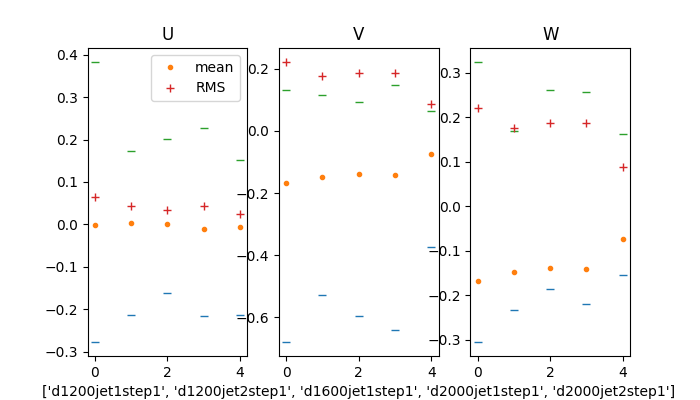

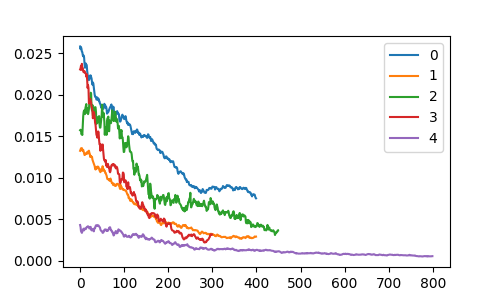

In [9]:
# jet statistics
data_labels = [ddd['data_title'] for ddd in dd_list]

plt.figure(figsize=(7, 4))
plt.subplot(131)
plt.title('U')
plt.plot(umin, '_')
plt.plot(umean, '.', label='mean')
plt.plot(umax, '_')
plt.plot(urms, '+', label='RMS')
plt.legend()

plt.subplot(132)
plt.title('V')
plt.plot(vmin, '_')
plt.plot(vmean, '.')
plt.plot(vmax, '_')
plt.plot(vrms, '+')
plt.xlabel(data_labels)

plt.subplot(133)
plt.title('W')
plt.plot(wmin, '_')
plt.plot(vmean, '.')
plt.plot(wmax, '_')
plt.plot(vrms, '+')
plt.show()

plt.figure(figsize=(5, 3))
plt.plot(tke[0], label='0')
plt.plot(tke[1], label='1')
plt.plot(tke[2], label='2')
plt.plot(tke[3], label='3')
plt.plot(tke[4], label='4')
plt.legend()
plt.show()


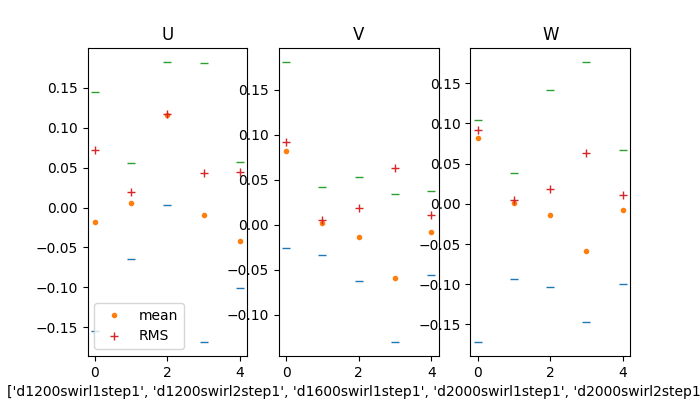

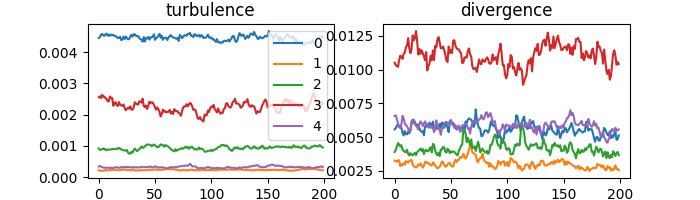

In [15]:
# swirl statistics
data_labels = [ddd['data_title'] for ddd in dd_list]

plt.figure(figsize=(7, 4))
plt.subplot(131)
plt.title('U')
plt.plot(umin, '_')
plt.plot(umean, '.', label='mean')
plt.plot(umax, '_')
plt.plot(urms, '+', label='RMS')
plt.legend()

plt.subplot(132)
plt.title('V')
plt.plot(vmin, '_')
plt.plot(vmean, '.')
plt.plot(vmax, '_')
plt.plot(vrms, '+')
plt.xlabel(data_labels)

plt.subplot(133)
plt.title('W')
plt.plot(wmin, '_')
plt.plot(vmean, '.')
plt.plot(wmax, '_')
plt.plot(vrms, '+')
plt.show()

plt.figure(figsize=(7, 2))
plt.subplot(121)
plt.title('turbulence')
plt.plot(tke[0], label='0')
plt.plot(tke[1], label='1')
plt.plot(tke[2], label='2')
plt.plot(tke[3], label='3')
plt.plot(tke[4], label='4')
plt.legend()
plt.subplot(122)
plt.title('divergence')
plt.plot(div[0], label='0')
plt.plot(div[1], label='1')
plt.plot(div[2], label='2')
plt.plot(div[3], label='3')
plt.plot(div[4], label='4')

plt.show()


In [8]:

# td_folder = '/zjbd/zd1/dafei/piv_training/jet160roi320'
# td_folder = '/zjbd/zd1/dafei/piv_training/jet160'

# td_folder = '/zjbd/zd1/dafei/piv_training/jet128r2'
# td_folder = '/zjbd/zd1/dafei/piv_training/jet128large'

# td_folder = '/zjbd/zd1/dafei/piv_training/jet128roi256'
# td_folder = '/zjbd/zd1/dafei/piv_training/swirl128'
# td_folder = '/zjbd/zd1/dafei/piv_training/swirl128roi256'
# td_folder = '/zjbd/zd1/dafei/piv_training/swirl160'

# td_folder = '/zjbd/zd1/dafei/piv_training/swirl160roi320'

# td_folder = '/zjbd/zd1/dafei/piv_training/jet256'
# td_folder = '/zjbd/zd1/dafei/piv_training/jet256r2'
# td_folder = '/zjbd/zd1/dafei/piv_training/jet160'
td_folder = '/zjbd/zd1/dafei/piv_training/jet320r2'

# sub_wh = 256  # patch size
# sub_wh = 160  # patch size
sub_wh = 320  # patch size

for dd in dd_list:
    shift = dd["roi_cropping_shift"]
    r_ids = np.arange(r0, r1-sub_wh+1, shift)
    c_ids = np.arange(c0, c1-sub_wh+1, shift)
    f0 = dd['f0'] 
    f1 = dd['f1']
    
    print(dd['data_title'])
    print(f'row number: {len(r_ids)}, column number: {len(c_ids)}')
    print(f'# samples: {len(r_ids)*len(c_ids)*(f1-f0)}')


d1200jet1step1
row number: 7, column number: 5
# samples: 19250
d1200jet2step1
row number: 7, column number: 5
# samples: 19250
d1600jet1step1
row number: 7, column number: 5
# samples: 22750
d2000jet1step1
row number: 7, column number: 5
# samples: 12250


In [9]:
# creat the training data folder
x_folder = os.path.join(td_folder, 'x')
y_folder = os.path.join(td_folder, 'y')
if os.path.exists(td_folder):  # delete the directory if it exists
    shutil.rmtree(td_folder)
os.makedirs(x_folder) # create folders
os.makedirs(y_folder)


In [10]:
labels_dict = {}
labels_dict["im_relative_ids"] = im_relative_ids
labels_dict["head_tail"] = head_tail
labels_dict['z0'] = z0
labels_dict['z1'] = z1
labels_dict['K_'] = K_
labels_dict['de_m'] = de_m

In [11]:
ylist = []
data_tags = []
for dd in dd_list:
    
    data_title = dd['data_title']
    data_tags.append(data_title)
    step = dd['step']
    print(f'dataset title: {data_title}')
    

    piv_files, im_files = match_piv_files(dd, head_tail)
    
    num_piv_files = len(piv_files)
    num_im_files = len(im_files)
    assert (num_piv_files+head_tail*2) == num_im_files, "piv-im mismatch"
    
    I, J, K = read_IJK_from_tecplot_dat(piv_files[0])
    
    shift = dd["roi_cropping_shift"]
    shift_uvw = int(shift/de_m)
    sub_wh_uvw = int(sub_wh/de_m)
    r_ids = np.arange(r0, r1-sub_wh+1, shift)
    c_ids = np.arange(c0, c1-sub_wh+1, shift)


    # im
    for i, im_file in enumerate(im_files):
        im = io.imread(im_file) # read the image one by one
        for ii, ridx in enumerate(r_ids):
            for jj, cidx in enumerate(c_ids):
                sub_im = im[ridx: ridx+sub_wh, cidx:cidx+sub_wh] # crop the image 
                rc_label = 'r'+str(ii).zfill(2)+'c'+str(jj).zfill(2)
                sub_im_name = rc_label + data_title + os.path.basename(im_file)  # sub-image name
                io.imsave(os.path.join(x_folder, sub_im_name), sub_im)
        
        if i % (num_im_files//2) == 0:
            print(f'image generation: {i+1}/{num_im_files}')
    print(f'image generation: {i+1}/{num_im_files}')
    
    # uvw
    for i, piv_file in enumerate(piv_files):
        piv = np.loadtxt(piv_file, skiprows=4)
        uvw_pts = transform_piv_data(piv, step, I, J, K, pts__)
        
        im_name_list = [os.path.basename(im_files[i+head_tail+p]) for p in im_relative_ids]
        
        for ii, ridx in enumerate(r_ids):
            for jj, cidx in enumerate(c_ids):
                rr0 = ii*shift_uvw
                cc0 = jj*shift_uvw
                sub_uvw = uvw_pts[:, :, rr0:rr0+sub_wh_uvw, cc0:cc0+sub_wh_uvw]
                rc_label = 'r'+str(ii).zfill(2)+'c'+str(jj).zfill(2)
                sub_uvw_name = rc_label + data_title+ os.path.basename(piv_file)[:-4] +'.npy'
                np.save(os.path.join(y_folder, sub_uvw_name), sub_uvw)
    
                im_label = [rc_label +  data_title + im_name for im_name in im_name_list]
                labels_dict[sub_uvw_name] = im_label

                ylist.append(sub_uvw_name)
        
        if i % (num_piv_files//2) == 0:
            print(f'velocity generation: {i+1}/{num_piv_files}')
    print(f'velocity generation: {i+1}/{num_piv_files}')

    
print('done')        



dataset title: d1200jet1step1
image generation: 1/560
image generation: 281/560
image generation: 560/560
velocity generation: 1/550
velocity generation: 276/550
velocity generation: 550/550
dataset title: d1200jet2step1
image generation: 1/560
image generation: 281/560
image generation: 560/560
velocity generation: 1/550
velocity generation: 276/550
velocity generation: 550/550
dataset title: d1600jet1step1
image generation: 1/660
image generation: 331/660
image generation: 660/660
velocity generation: 1/650
velocity generation: 326/650
velocity generation: 650/650
dataset title: d2000jet1step1
image generation: 1/360
image generation: 181/360
image generation: 360/360
velocity generation: 1/350
velocity generation: 176/350
velocity generation: 350/350
done


In [12]:
labels_dict['data_tags'] = data_tags

with open(os.path.join(td_folder, "labels.pickle"), 'wb') as handle:
    pickle.dump(labels_dict, handle, protocol=pickle.HIGHEST_PROTOCOL) 